# Capstone Project Gantt Chart

Stablecoin Depeg Prediction — Project Timeline & Deliverables

In [1]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from datetime import datetime, timedelta
import numpy as np

In [2]:
# === Phase & Task Definitions ===
phases = [
    {
        "phase": "Kickoff",
        "start": "2026-02-01",
        "end": "2026-02-12",
        "color": "#898E92",
        "tasks": [
            {"name": "Project Scope Definition and Signoff", "start": "2026-02-01", "end": "2026-02-12"},
            {"name": "Project Plan Draft and Signoff", "start": "2026-02-07", "end": "2026-02-12"},
        ],
        "deliverables": [
            {"name": "Scope Artefact", "date": "2026-02-12"},
            {"name": "Project Plan Artefact", "date": "2026-02-12"},
        ],
    },
    {
        "phase": "Data Foundation & Background", #some dependencies on phase 0
        "start": "2026-02-01",
        "end": "2026-02-28",
        "color": "#2196F3",
        "tasks": [
            {"name": "Stablecoin background research", "start": "2026-02-01", "end": "2026-02-14"},
            {"name": "Data collection (all sources)", "start": "2026-02-07", "end": "2026-02-15"}, #already started on scripts
            {"name": "Depeg event cataloging", "start": "2026-02-10", "end": "2026-02-17"},
            {"name": "Merge pipeline & standardization & data quality", "start": "2026-02-15", "end": "2026-02-25"}, #started already
            {"name": "Storytelling narrative & UST/Terra case study", "start": "2026-02-12", "end": "2026-02-28"}, #story telling in parallel
        ],
        "deliverables": [
            {"name": "", "date": "2026-02-28"},
            {"name": "Raw data sourcing complete (all sources)", "date": "2026-02-16"},
            {"name": "Depeg event catalog", "date": "2026-02-15"},
            {"name": "Standardized merged datasets", "date": "2026-02-25"},
            {"name": "Background & UST slides / report", "date": "2026-02-28"},
        ],
    },
    {
        "phase": "Feature Engineering & EDA",
        "start": "2026-03-01",
        "end": "2026-03-14",
        "color": "#4CAF50",
        "tasks": [
            {"name": "EDA notebooks & visualizations", "start": "2026-03-01", "end": "2026-03-06"},
            {"name": "Feature Engineering", "start": "2026-03-04", "end": "2026-03-11"},
            {"name": "Midpoint Presentation", "start": "2026-03-01", "end": "2026-03-12"},
        ],
        "deliverables": [
            {"name": "EDA notebooks finalized", "date": "2026-03-05"},
            {"name": "Feature engineering pipeline", "date": "2026-03-06"},
            {"name": "Midpoint presentation", "date": "2026-03-12"},
        ],
    },
    {
        "phase": "Modeling & Evaluation",
        "start": "2026-03-14",
        "end": "2026-03-31",
        "color": "#FF9800",
        "tasks": [
            {"name": "Baseline models (LR, RF, GB)", "start": "2026-03-14", "end": "2026-03-17"},
            {"name": "Advanced models (XGBoost/LSTM)", "start": "2026-03-17", "end": "2026-03-21"},
            {"name": "Backtesting", "start": "2026-03-21", "end": "2026-03-25"},
            {"name": "Feature importance (SHAP)", "start": "2026-03-20", "end": "2026-03-26"},
            {"name": "Presentation / Report updating", "start": "2026-03-14", "end": "2026-03-28"},
        ],
        "deliverables": [
            {"name": "Model pipeline script/notebook", "date": "2026-03-22"},
            {"name": "Model comparison table", "date": "2026-03-22"},
            {"name": "Backtesting results", "date": "2026-03-25"},
            {"name": "SHAP analysis & visuals", "date": "2026-03-27"},
            {"name": "Updated WIP Presentation/Report", "date": "2026-03-28"}, #at this point we should have background, UST case study, descriptive analytics, at least skeleton for the modeling
        ],
    },
    {
        "phase": "Report & Presentation",
        "start": "2026-04-01",
        "end": "2026-04-22",
        "color": "#9C27B0",
        "tasks": [
            {"name": "Final report/presentation writing", "start": "2026-04-01", "end": "2026-04-11"},
            {"name": "Presentation deck / prep", "start": "2026-04-11", "end": "2026-04-18"},
            {"name": "Class and Client Presentations", "start": "2026-04-20", "end": "2026-04-22"},
           
        ],
        "deliverables": [
            {"name": "Draft final report", "date": "2026-04-11"},
            {"name": "Polished final report and presentation ready", "date": "2026-04-18"},
            {"name": "Presentations to class and client", "date": "2026-04-25"},
        ],
    },
]


milestones = [
    {"name": "Midpoint Review", "date": "2026-03-12", "color": "#F44336"},
    {"name": "Final Deadline", "date": "2026-04-22", "color": "#F44336"},
]

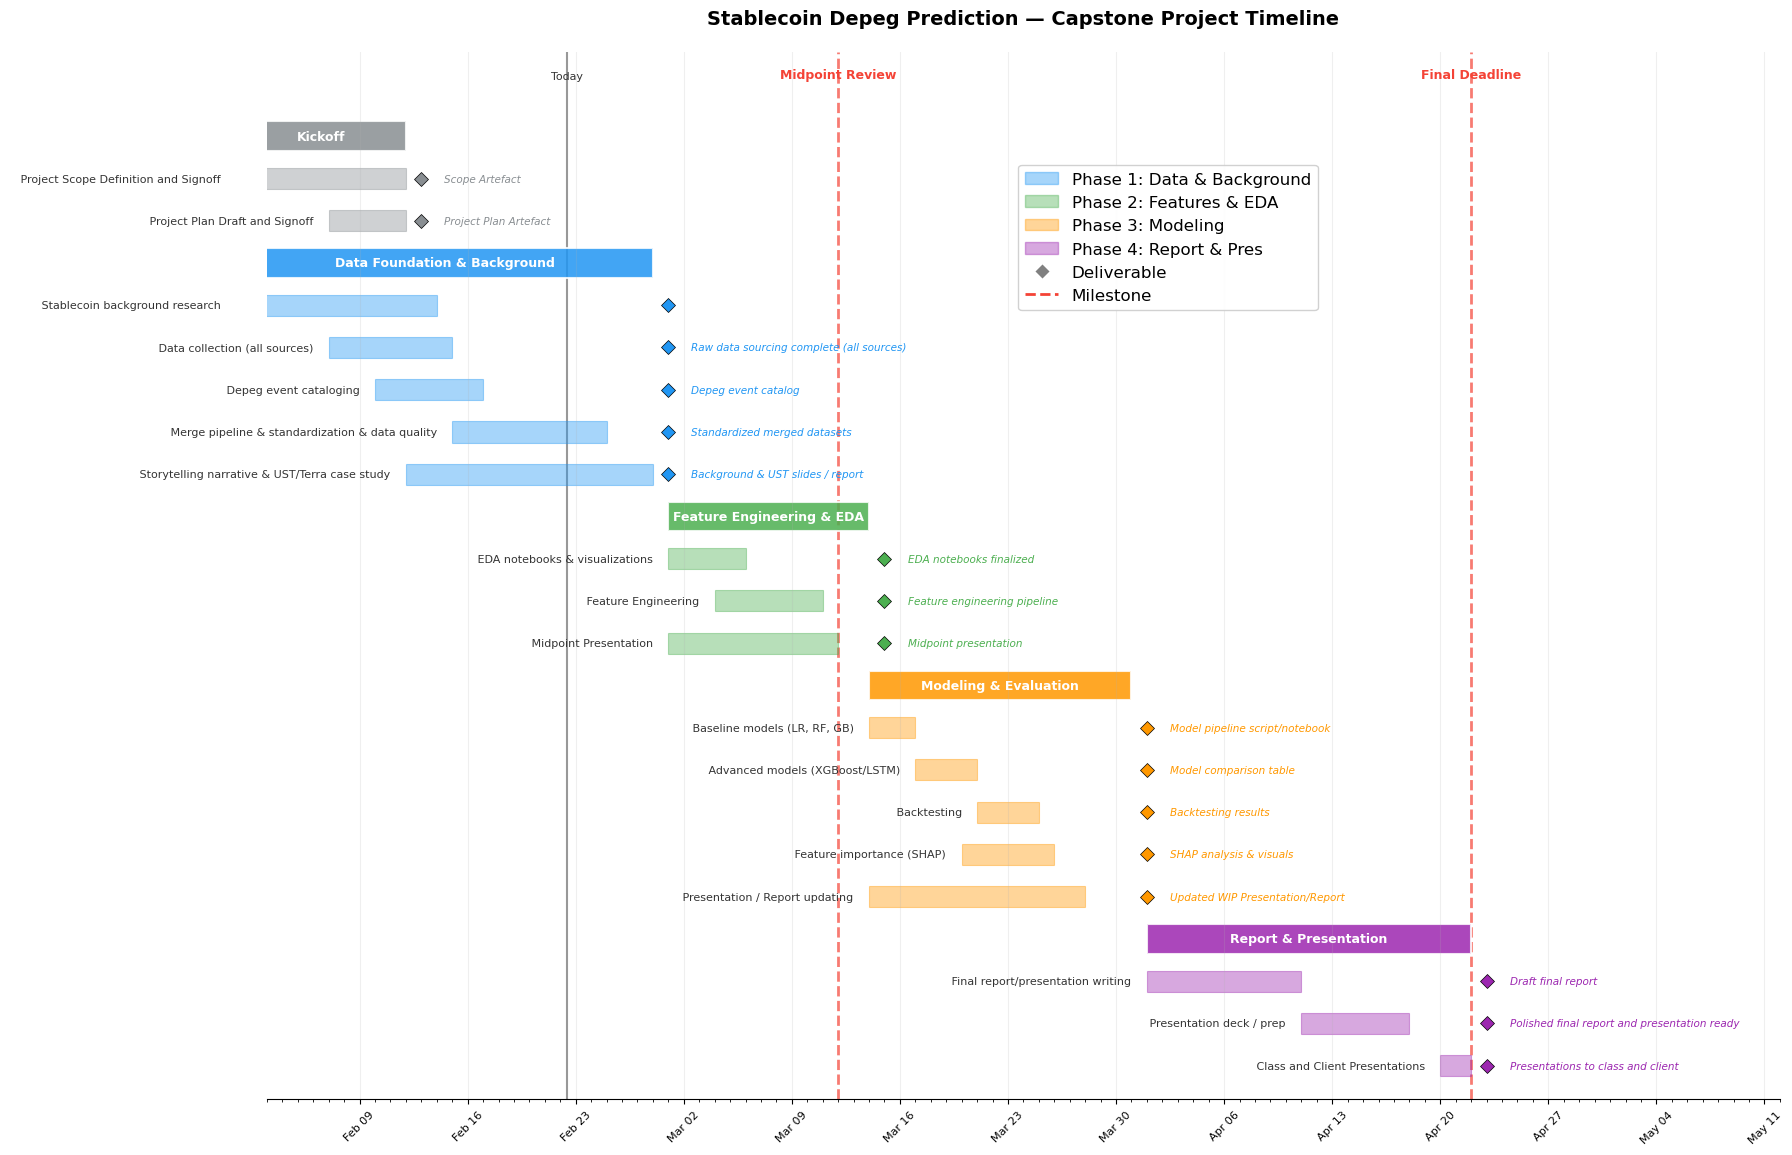

Saved to docs/gantt_chart.png


In [3]:
# === Build the Gantt Chart ===

def parse_date(s):
    return datetime.strptime(s, "%Y-%m-%d")

# Build rows: only phases and tasks (no separate deliverable rows)
# Deliverables get attached to the last N task rows of each phase
rows = []       # (label, start, end, color, row_type)
deliverable_map = {}  # row_index -> (deliverable_label, phase_end, color)

for phase in phases:
    phase_end = parse_date(phase["end"])
    rows.append((phase["phase"], parse_date(phase["start"]), phase_end, phase["color"], "phase"))

    task_start_idx = len(rows)
    for task in phase["tasks"]:
        rows.append(("   " + task["name"], parse_date(task["start"]), parse_date(task["end"]), phase["color"], "task"))

    # Attach deliverables to the last N task rows
    num_deliverables = len(phase["deliverables"])
    for j, d in enumerate(phase["deliverables"]):
        task_row_idx = task_start_idx + len(phase["tasks"]) - num_deliverables + j
        deliverable_map[task_row_idx] = (d["name"], phase_end, phase["color"])

# Reverse for top-down display
rows = rows[::-1]
n = len(rows)

# Remap deliverable indices after reversal
reversed_deliverable_map = {}
for orig_idx, val in deliverable_map.items():
    reversed_deliverable_map[n - 1 - orig_idx] = val

fig, ax = plt.subplots(figsize=(18, n * 0.42 + 2))

for i, (label, start, end, color, row_type) in enumerate(rows):
    if row_type == "phase":
        duration = (end - start).days or 1
        ax.barh(i, duration, left=start, height=0.7, color=color, alpha=0.85, edgecolor="white", linewidth=1.5)
        ax.text(start + timedelta(days=duration / 2), i, label, ha="center", va="center",
                fontsize=9, fontweight="bold", color="white")
    elif row_type == "task":
        duration = (end - start).days or 1
        ax.barh(i, duration, left=start, height=0.5, color=color, alpha=0.4, edgecolor=color, linewidth=0.8)
        ax.text(start - timedelta(days=1), i, label, ha="right", va="center", fontsize=8, color="#333")

    # If this row has an attached deliverable, draw it to the right
    if i in reversed_deliverable_map:
        d_label, phase_end, d_color = reversed_deliverable_map[i]
        ax.plot(phase_end + timedelta(days=1), i, marker="D", markersize=7, color=d_color,
                markeredgecolor="black", markeredgewidth=0.5)
        ax.text(phase_end + timedelta(days=2.5), i, d_label, ha="left", va="center", fontsize=7.5,
                color=d_color, fontstyle="italic")

# Milestone vertical lines
for ms in milestones:
    d = parse_date(ms["date"])
    ax.axvline(d, color=ms["color"], linewidth=2, linestyle="--", alpha=0.7, zorder=0)
    ax.text(d, n + 0.3, ms["name"], ha="center", va="bottom", fontsize=9,
            fontweight="bold", color=ms["color"])

# Today line
today = datetime.now()
if parse_date("2026-02-01") <= today <= parse_date("2026-04-30"):
    ax.axvline(today, color="#333", linewidth=1.5, linestyle="-", alpha=0.5, zorder=0)
    ax.text(today, n + 0.3, "Today", ha="center", va="bottom", fontsize=8, color="#333")

# Formatting
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_minor_locator(mdates.DayLocator())
plt.xticks(rotation=45, fontsize=8)

ax.set_xlim(parse_date("2026-02-03"), parse_date("2026-05-12"))
ax.set_ylim(-0.8, n + 1)
ax.set_yticks([])

ax.spines["left"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.grid(axis="x", alpha=0.2, which="major")

# Legend
legend_elements = [
    mpatches.Patch(facecolor="#2196F3", alpha=0.4, edgecolor="#2196F3", label="Phase 1: Data & Background"),
    mpatches.Patch(facecolor="#4CAF50", alpha=0.4, edgecolor="#4CAF50", label="Phase 2: Features & EDA"),
    mpatches.Patch(facecolor="#FF9800", alpha=0.4, edgecolor="#FF9800", label="Phase 3: Modeling"),
    mpatches.Patch(facecolor="#9C27B0", alpha=0.4, edgecolor="#9C27B0", label="Phase 4: Report & Pres"),
    plt.Line2D([0], [0], marker="D", color="w", markerfacecolor="gray", markersize=8, label="Deliverable"),
    plt.Line2D([0], [0], color="#F44336", linewidth=2, linestyle="--", label="Milestone"),
]
ax.legend(handles=legend_elements, loc="upper right", fontsize=12, framealpha=0.9, bbox_to_anchor=(0.7, 0.9))

ax.set_title("Stablecoin Depeg Prediction — Capstone Project Timeline",
             fontsize=14, fontweight="bold", pad=20)

plt.tight_layout()
plt.savefig("../docs/gantt_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to docs/gantt_chart.png")